In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_explore(filename):
    df = pd.read_csv(filename)
    
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nFirst 5 rows:\n", df.head())
    print("\nMissing Values:\n", df.isnull().sum())
    
    return df

df = load_and_explore("E:\\supermarket_sales.csv")

Shape: (2000, 14)

Columns: ['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender', 'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date', 'Time', 'Payment', 'Rating']

First 5 rows:
   Invoice_ID Branch       City Customer_Type  Gender         Product_Line  \
0  INV000001      B   Mandalay        Member    Male     Food & Beverages   
1  INV000002      C   Mandalay        Member  Female     Food & Beverages   
2  INV000003      C  Naypyitaw        Normal  Female  Fashion Accessories   
3  INV000004      B  Naypyitaw        Member  Female     Food & Beverages   
4  INV000005      C     Yangon        Normal  Female     Food & Beverages   

   Unit_Price  Quantity   Tax   Total        Date   Time      Payment  Rating  
0       69.36         3  7.28  119.58  2023-08-08  18:54  Credit card     8.4  
1       35.25         1  6.62  137.13  2023-02-09  18:44  Credit card     4.3  
2       57.56         8  4.66  490.48  2023-08-24  16:16         Cash     9.6  
3       16.60     

In [15]:
df = df.drop_duplicates()

In [23]:
df.ffill(inplace=True)

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [48]:
df['Revenue'] = df['Quantity'] * df['Unit_Price']
print(df['Revenue'])

0       208.08
1        35.25
2       460.48
3        83.00
4        49.07
         ...  
1995    518.85
1996    385.52
1997    163.17
1998    287.28
1999    156.00
Name: Revenue, Length: 2000, dtype: float64


In [27]:
# Check negative values
print(df[df['Quantity'] < 0])

# Summary statistics
print(df.describe())

Empty DataFrame
Columns: [Invoice_ID, Branch, City, Customer_Type, Gender, Product_Line, Unit_Price, Quantity, Tax, Total, Date, Time, Payment, Rating, Revenue]
Index: []
        Unit_Price   Quantity          Tax        Total  \
count  2000.000000  2000.0000  2000.000000  2000.000000   
mean     55.258490     5.0330     5.512745   259.640345   
min      10.010000     1.0000     1.000000    20.370000   
25%      33.615000     3.0000     3.317500   137.872500   
50%      55.610000     5.0000     5.440000   258.040000   
75%      77.500000     7.0000     7.742500   386.937500   
max      99.920000     9.0000    10.000000   499.910000   
std      25.813536     2.6087     2.582829   138.930861   

                                Date       Rating      Revenue  
count                           2000  2000.000000  2000.000000  
mean   2023-07-04 00:27:21.600000256     6.957600   279.566250  
min              2023-01-01 00:00:00     4.000000    10.210000  
25%              2023-04-05 00:00:00 

In [38]:
#Daily Sales Trend

daily_sales = df.groupby('Date')['Revenue'].sum()
print(daily_sales)

Date
2023-01-01    1266.37
2023-01-02    2113.24
2023-01-03     761.10
2023-01-04    1562.26
2023-01-05    1127.76
               ...   
2023-12-27    2095.41
2023-12-28    2352.84
2023-12-29    1862.00
2023-12-30    1666.90
2023-12-31     692.83
Name: Revenue, Length: 364, dtype: float64


In [40]:
#Best-Selling Products

best_products = df.groupby('Product_Line')['Quantity'].sum().sort_values(ascending=False)
print(best_products)

Product_Line
Health & Beauty           1866
Sports & Travel           1737
Electronic Accessories    1691
Home & Lifestyle          1654
Food & Beverages          1618
Fashion Accessories       1500
Name: Quantity, dtype: int64


In [41]:
#Customer Behavior

customer_spending = df.groupby('Customer_Type')['Revenue'].mean()
print(customer_spending)

Customer_Type
Member    284.025963
Normal    274.943045
Name: Revenue, dtype: float64


In [42]:
#Payment Analysis

payment_method = df['Payment'].value_counts()
print(payment_method)

Payment
Ewallet        720
Cash           658
Credit card    622
Name: count, dtype: int64


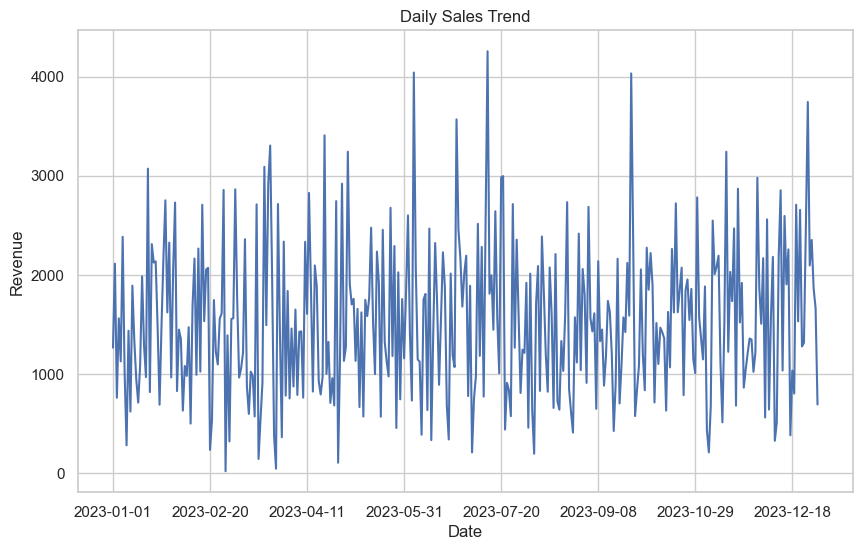

In [44]:
#Daily Sales Trend (Line Chart)

plt.figure()
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

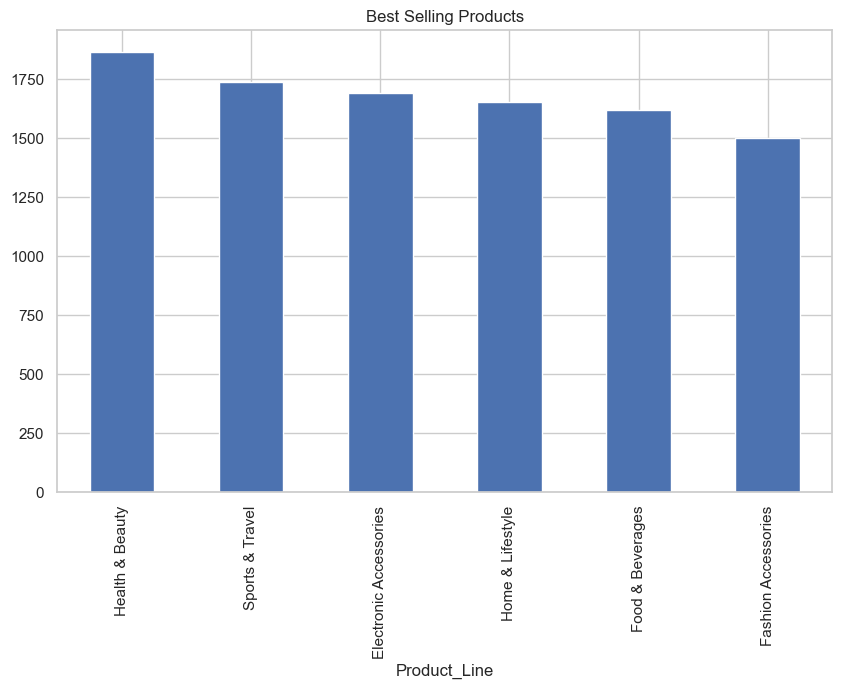

In [45]:
#Best Products (Bar Chart)

plt.figure()
best_products.plot(kind='bar')
plt.title("Best Selling Products")
plt.show()

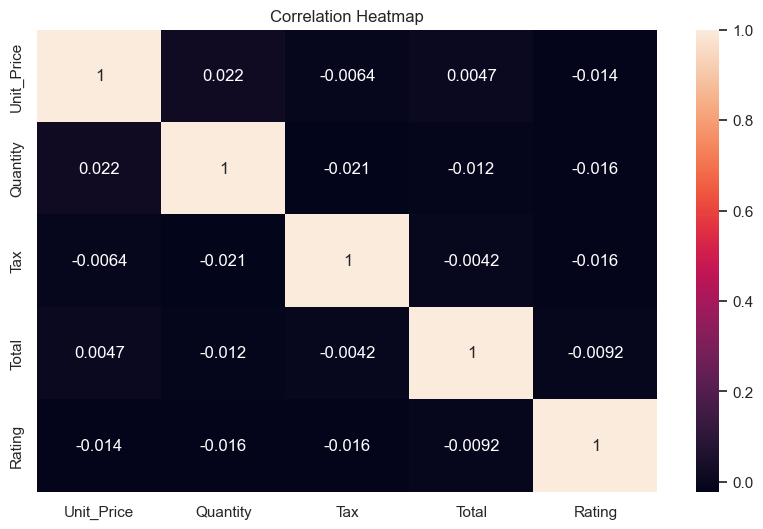

In [46]:
#Correlation Heatmap

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [49]:
#Mean, Median, Std

mean_rev = df['Revenue'].mean()
median_rev = df['Revenue'].median()
std_rev = df['Revenue'].std()

print(mean_rev)
print(median_rev)
print(std_rev)

279.56625
219.87
206.7237382039276


In [51]:
#Correlation

correlation = df[['Quantity', 'Unit_Price', 'Revenue']].corr()
print(correlation)

            Quantity  Unit_Price   Revenue
Quantity    1.000000    0.021547  0.713649
Unit_Price  0.021547    1.000000  0.637384
Revenue     0.713649    0.637384  1.000000


In [58]:
#Monthly Trends

df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.month)['Revenue'].sum()
print(monthly_sales)

Date
1     46742.33
2     40466.80
3     44226.62
4     43296.81
5     48537.15
6     49526.11
7     51570.98
8     41998.54
9     45162.23
10    47838.00
11    46414.58
12    53352.35
Name: Revenue, dtype: float64
